<a href="https://colab.research.google.com/github/22104071/Quantitative_Market_Research_Project/blob/main/ML_model_for__best__strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

**Data Preprocessing**

In [4]:
df = pd.read_csv('/content/NIFTY 50-01-04-2024-to-31-03-2025.csv')
ml_df = df.copy()

In [5]:
print(ml_df.head())

         Date      Open      High      Low     Close   Shares Traded   \
0  28-MAR-2025  23600.40  23649.20  23450.2  23519.35       387455531   
1  27-MAR-2025  23433.95  23646.45  23412.2  23591.95       510302142   
2  26-MAR-2025  23700.95  23736.50  23451.7  23486.85       278590831   
3  25-MAR-2025  23751.50  23869.60  23601.4  23668.65       338216746   
4  24-MAR-2025  23515.40  23708.75  23433.5  23658.35       311900413   

   Turnover (₹ Cr)  
0         29156.37  
1         46481.84  
2         26877.28  
3         35415.03  
4         28871.35  


**Feature Engineering for ML**

In [ ]:
ml_df['Return_1D'] = ml_df['Close '].pct_change()

ml_df['Return_5D'] = ml_df['Close '].pct_change(5)

ml_df['Return_10D'] = ml_df['Close '].pct_change(10)

ml_df['Return_20D'] = ml_df['Close '].pct_change(20)

ml_df['Volatility_20D'] = (
    ml_df['Return_1D']
    .rolling(20)
    .std()
)

In [ ]:
#Moving Average
ml_df['SMA_10'] = ml_df['Close '].rolling(window=10).mean()
ml_df['SMA_50'] = ml_df['Close '].rolling(window=50).mean()

In [ ]:
ml_df['Trend_Strength'] = (
    (ml_df['SMA_10'] - ml_df['SMA_50'])
    / ml_df['SMA_50']
)

ml_df['Price_vs_SMA_10'] = (
    (ml_df['Close '] - ml_df['SMA_10'])
    / ml_df['SMA_10']
)

**Future Market Labels**

In [17]:
ml_df['Future_Return'] = (
    ml_df['Close ']
    .shift(-5)
    /
    ml_df['Close ']
    - 1
)

In [18]:
def classify_market(x):

    if x > 0.02:
        return 2

    elif x < -0.02:
        return 0

    else:
        return 1

ml_df['Regime'] = (
    ml_df['Future_Return']
    .apply(classify_market)
)

**Defining Features**

In [19]:
features = [

    'Return_1D',
    'Return_5D',
    'Return_10D',
    'Return_20D',

    'Volatility_20D',

    'Trend_Strength',

    'Price_vs_SMA_10'

]

**Prepare Dataset**

In [20]:
ml_df = ml_df.dropna()

X = ml_df[features]

y = ml_df['Regime']

**Training and Testing Data**

In [21]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]

X_test = X.iloc[split:]

y_train = y.iloc[:split]

y_test = y.iloc[split:]

In [22]:
# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=6,

    min_samples_leaf=5,

    random_state=42

)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=5, n_estimators=300,
                       random_state=42)

**Predictions**

In [23]:
predictions = rf.predict(X_test)

**Model Evaluation**

In [ ]:
print("\nAccuracy")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

print("\nClassification Report")

print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix")

print(
    confusion_matrix(
        y_test,
        predictions
    )
)

**Feature Importance**

In [25]:
importance = pd.DataFrame({

    'Feature': features,

    'Importance':
    rf.feature_importances_

})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

           Feature  Importance
5   Trend_Strength    0.235018
4   Volatility_20D    0.193953
1        Return_5D    0.156681
2       Return_10D    0.140210
6  Price_vs_SMA_10    0.109898
3       Return_20D    0.100700
0        Return_1D    0.063539


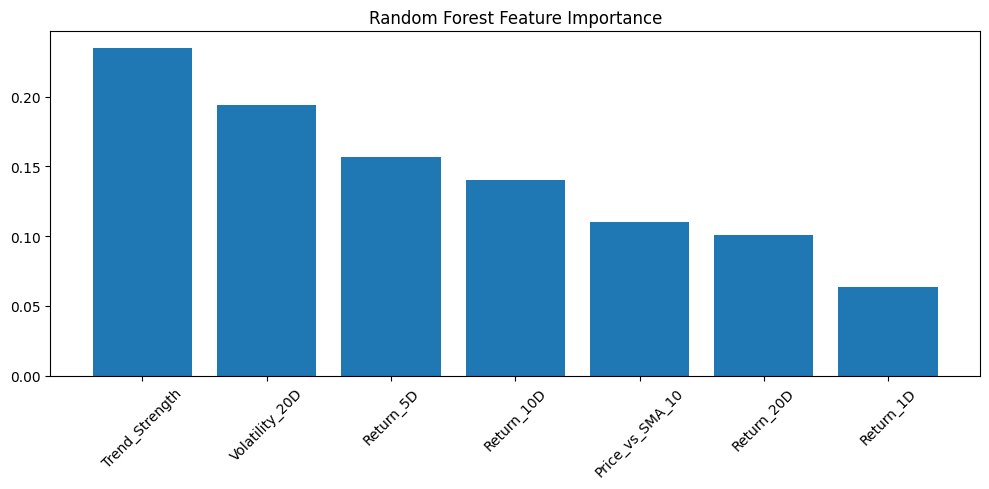

In [26]:
plt.figure(figsize=(10,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.show()

In [27]:
# ============================================================
# STRATEGY RECOMMENDATION ENGINE
# ============================================================

def recommend_strategy(regime):

    if regime == 2:

        return "Buy & Hold"

    elif regime == 1:

        return "Momentum"

    else:

        return "Cash"

**Generating Recommendations**

In [28]:
recommendations = [

    recommend_strategy(x)

    for x in predictions

]

recommendation_df = pd.DataFrame({

    'Actual_Regime': y_test.values,

    'Predicted_Regime': predictions,

    'Recommended_Strategy': recommendations

})

print(
    recommendation_df.head(20)
)

    Actual_Regime  Predicted_Regime Recommended_Strategy
0               2                 1             Momentum
1               1                 1             Momentum
2               1                 1             Momentum
3               2                 1             Momentum
4               1                 1             Momentum
5               1                 1             Momentum
6               1                 1             Momentum
7               0                 1             Momentum
8               0                 1             Momentum
9               1                 1             Momentum
10              1                 1             Momentum
11              1                 1             Momentum
12              1                 1             Momentum
13              1                 1             Momentum
14              1                 1             Momentum
15              1                 1             Momentum
16              1              

**Suggesting Best Strategy**

In [29]:
latest_features = X.tail(1)

latest_prediction = rf.predict(
    latest_features
)[0]

latest_strategy = recommend_strategy(
    latest_prediction
)

print(
    "\nSuggested Strategy:",
    latest_strategy
)


Suggested Strategy: Momentum
